# JUG: Noise Models in Pulsar Timing

Pulsar TOA uncertainties have structure beyond simple white noise.  For J1909-3744 the
NANOGrav noise model includes:

| Process | Symbol | Effect |
|---------|--------|--------|
| EFAC | $E$ | Rescales TOA uncertainties per backend — accounts for underestimated radiometer noise |
| EQUAD | $Q$ | Adds in quadrature per backend — pulse-phase jitter and other floor noise |
| ECORR | $J$ | Epoch-level correlated noise — simultaneously observed TOAs at different frequencies share the same pulse-arrival jitter |

ECORR is the key correlated noise: two TOAs taken in the same observing session (same epoch,
different frequencies) are shifted together by the same jitter.  Ignoring this correlation
inflates the effective number of independent data points and gives over-confident parameter
uncertainties.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # suppress PjRt C++ log spam

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from jug.engine.session import TimingSession
from jug.engine.flag_mapping import resolve_backends

FULL_PAR = "../data/pulsars/NG_15yr_partim/J1909-3744_PINT_20220303.nb.par"
PAR   = "../data/pulsars/J1909-3744_demo.par"  # DM1+DM2+ECORR only — no DMX/red-noise → fast GLS
TIM   = "../data/pulsars/NG_15yr_partim/J1909-3744_PINT_20220303.nb.tim"
CLOCK = "../data/clock"

> **Performance note:** The first execution compiles JAX kernels for this machine (~1–3 minutes).
> Subsequent runs use the on-disk compilation cache and complete in seconds.
> Run this notebook once before your presentation to warm the cache.

## Load and fit

In [2]:
session = TimingSession(PAR, TIM, clock_dir=CLOCK, verbose=False)
fit = session.fit_parameters(max_iter=3, verbose=False)

mjd      = np.array(fit['tdb_mjd'])
res_us   = np.array(fit['residuals_us'])
pre_us   = np.array(fit['residuals_prefit_us'])
err_us   = np.array(fit['errors_us'])
noise    = fit['noise_realizations']

print("Available noise realizations:", [k for k in noise if not k.endswith('_err')])
print(f"TOAs: {len(mjd)}   Post-fit RMS: {fit['final_rms']:.4f} µs")

[!] Unrecognized par file parameters (ignored by JUG): CLOCK, DMDATA, ECL


[FITTER] noise_config was None, auto-detecting from par file


Available noise realizations: ['ECORR']
TOAs: 35037   Post-fit RMS: 0.2223 µs


## Backend colouring

J1909-3744 has been observed by four receiver+backend combinations.  We colour each
separately to show that ECORR operates within epochs, not within backends.

In [3]:
toa_flags   = [t.flags for t in session.toas_data]
backend_arr = resolve_backends(toa_flags)
unique_backends = sorted(set(backend_arr))

PALETTE = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#e67e22', '#1abc9c']
bknd_colors = {b: PALETTE[i % len(PALETTE)] for i, b in enumerate(unique_backends)}

print("Backends:", unique_backends)

Backends: ['3GHz_YUPPI', 'Rcvr1_2_GASP', 'Rcvr1_2_GUPPI', 'Rcvr_800_GASP', 'Rcvr_800_GUPPI']


## ECORR: epoch-level correlated noise

Each cluster of points at the same MJD (same observing session, different frequency
sub-bands) shares one ECORR jitter value.  The ECORR realization is flat within each
epoch — you can see it as a common offset applied to all colours at that epoch.

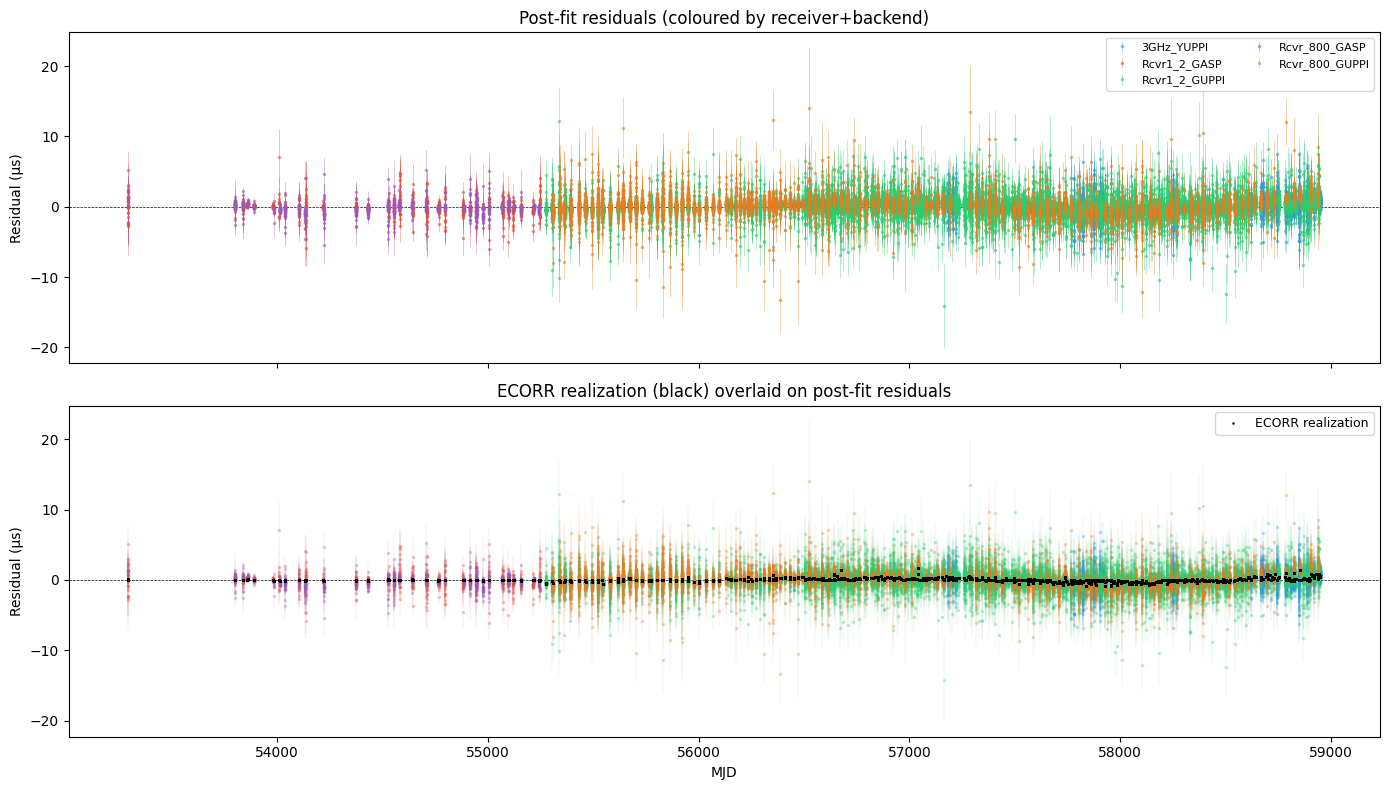

In [4]:
ecorr_us = noise.get('ECORR', np.zeros_like(res_us))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Post-fit residuals coloured by backend
ax = axes[0]
for b in unique_backends:
    mask = np.array(backend_arr) == b
    ax.errorbar(mjd[mask], res_us[mask], err_us[mask],
                fmt='.', ms=3, alpha=0.5, color=bknd_colors[b],
                elinewidth=0.5, label=b)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_ylabel('Residual (µs)')
ax.set_title('Post-fit residuals (coloured by receiver+backend)')
ax.legend(loc='upper right', ncol=2, fontsize=8)

# ECORR realization overlaid
ax = axes[1]
for b in unique_backends:
    mask = np.array(backend_arr) == b
    ax.errorbar(mjd[mask], res_us[mask], err_us[mask],
                fmt='.', ms=3, alpha=0.25, color=bknd_colors[b],
                elinewidth=0.3)
ax.plot(mjd, ecorr_us, 'k.', ms=2, alpha=0.7, label='ECORR realization', zorder=5)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_ylabel('Residual (µs)')
ax.set_title('ECORR realization (black) overlaid on post-fit residuals')
ax.legend(fontsize=9)
ax.set_xlabel('MJD')

plt.tight_layout()
plt.show()

## All noise components

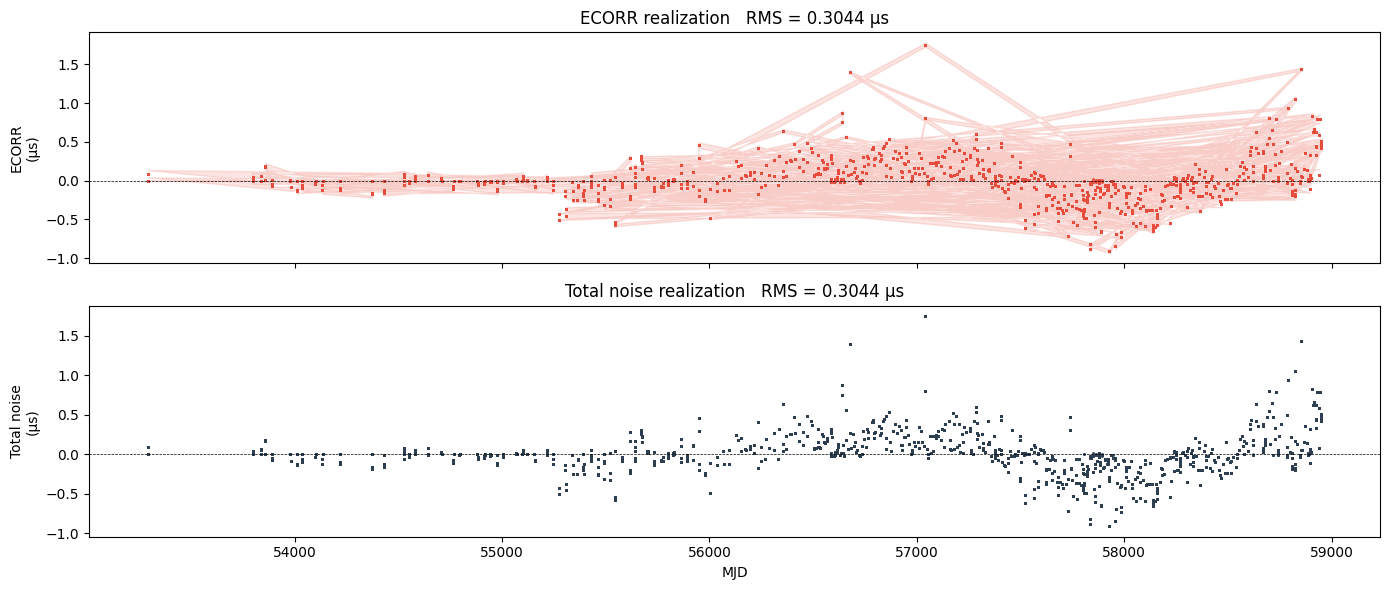

In [5]:
noise_keys = [k for k in noise if not k.endswith('_err')]
total_noise = np.zeros(len(res_us))
for k in noise_keys:
    v = np.array(noise[k])
    if len(v) == len(res_us):
        total_noise += v

n_panels = len(noise_keys) + 1
fig, axes = plt.subplots(n_panels, 1, figsize=(14, 3 * n_panels), sharex=True)
if n_panels == 1:
    axes = [axes]

noise_colors = {'ECORR': '#e74c3c', 'RedNoise': '#3498db',
                'DMNoise': '#2ecc71', 'ChromaticNoise': '#9b59b6'}

for i, k in enumerate(noise_keys):
    ax = axes[i]
    v = np.array(noise[k])
    color = noise_colors.get(k, '#e67e22')
    ax.plot(mjd, v, '.', ms=2, color=color, alpha=0.7)
    if f'{k}_err' in noise:
        err_v = np.array(noise[f'{k}_err'])
        ax.fill_between(mjd, v - err_v, v + err_v, alpha=0.15, color=color)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    rms_n = np.sqrt(np.mean(v**2))
    ax.set_ylabel(f'{k}\n(µs)')
    ax.set_title(f'{k} realization   RMS = {rms_n:.4f} µs')

# Total noise
ax = axes[-1]
ax.plot(mjd, total_noise, '.', ms=2, color='#2c3e50', alpha=0.7)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_ylabel('Total noise\n(µs)')
ax.set_title(f'Total noise realization   RMS = {np.sqrt(np.mean(total_noise**2)):.4f} µs')
ax.set_xlabel('MJD')

plt.tight_layout()
plt.show()

## Pre-fit → Post-fit → Whitened

Subtracting the noise realization from the post-fit residuals gives the **whitened** residuals.
These should be purely white (uncorrelated) if the noise model is correct.

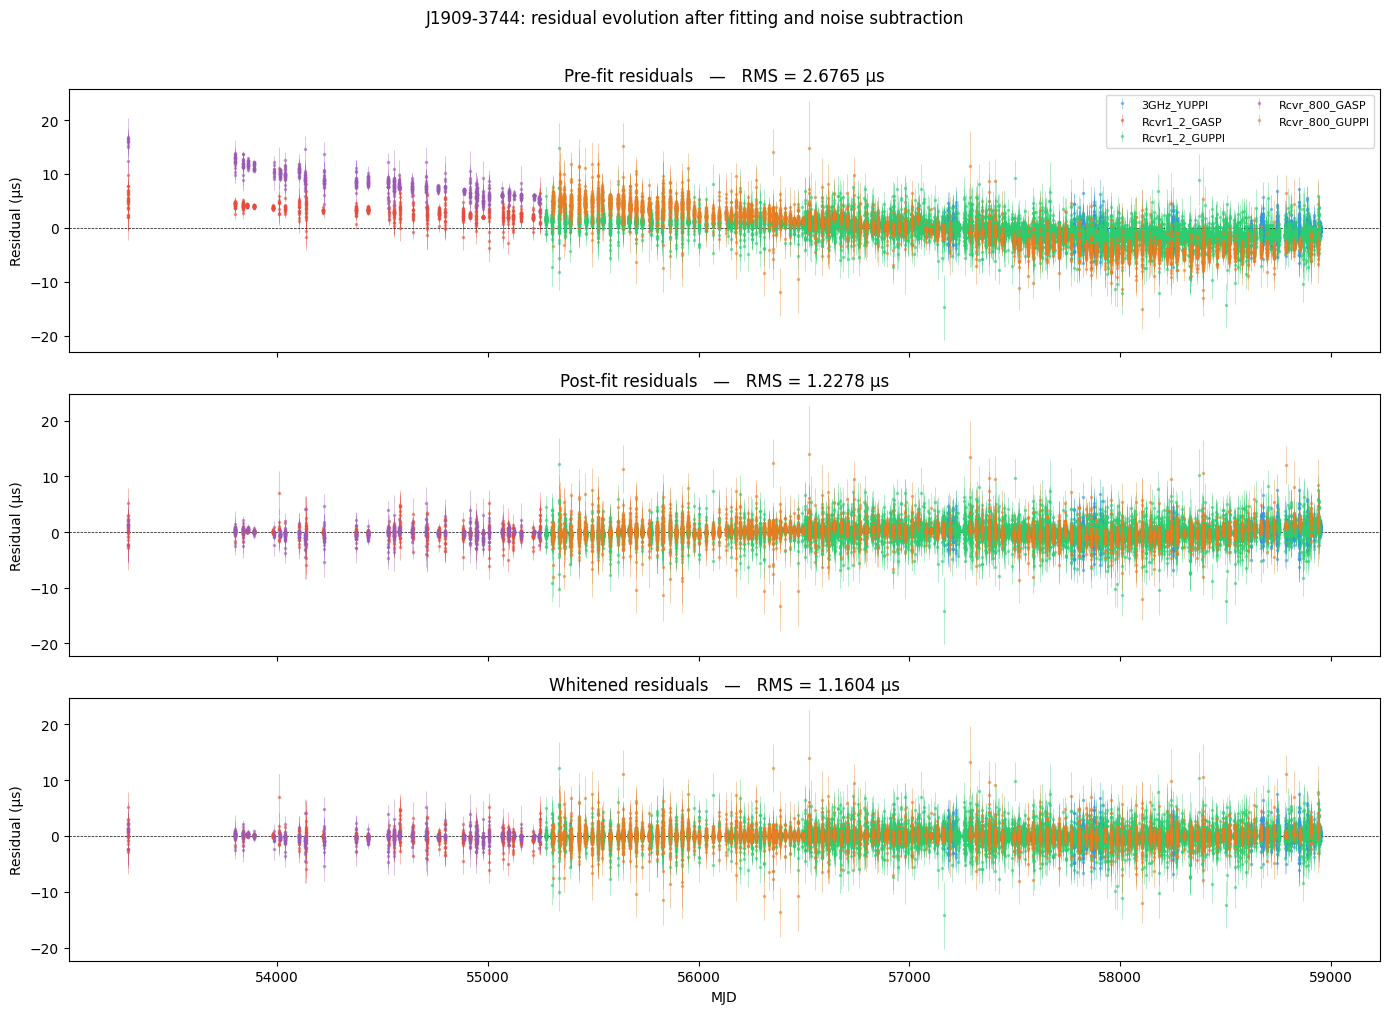

In [6]:
whitened_us = res_us - total_noise

prefit_rms  = np.sqrt(np.mean(pre_us**2))
postfit_rms = np.sqrt(np.mean(res_us**2))
white_rms   = np.sqrt(np.mean(whitened_us**2))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, y, title, rms in [
    (axes[0], pre_us,      'Pre-fit residuals',      prefit_rms),
    (axes[1], res_us,      'Post-fit residuals',     postfit_rms),
    (axes[2], whitened_us, 'Whitened residuals',     white_rms),
]:
    for b in unique_backends:
        mask = np.array(backend_arr) == b
        ax.errorbar(mjd[mask], y[mask], err_us[mask],
                    fmt='.', ms=3, alpha=0.5, color=bknd_colors[b],
                    elinewidth=0.5, label=b)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylabel('Residual (µs)')
    ax.set_title(f"{title}   —   RMS = {rms:.4f} µs")

axes[0].legend(loc='upper right', ncol=2, fontsize=8)
axes[-1].set_xlabel('MJD')
fig.suptitle('J1909-3744: residual evolution after fitting and noise subtraction',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Gaussianity of whitened residuals

If the noise model is correctly specified, whitened residuals normalised by the TOA
uncertainty should follow $\mathcal{N}(0,1)$.  We test this with the
Anderson–Darling statistic.

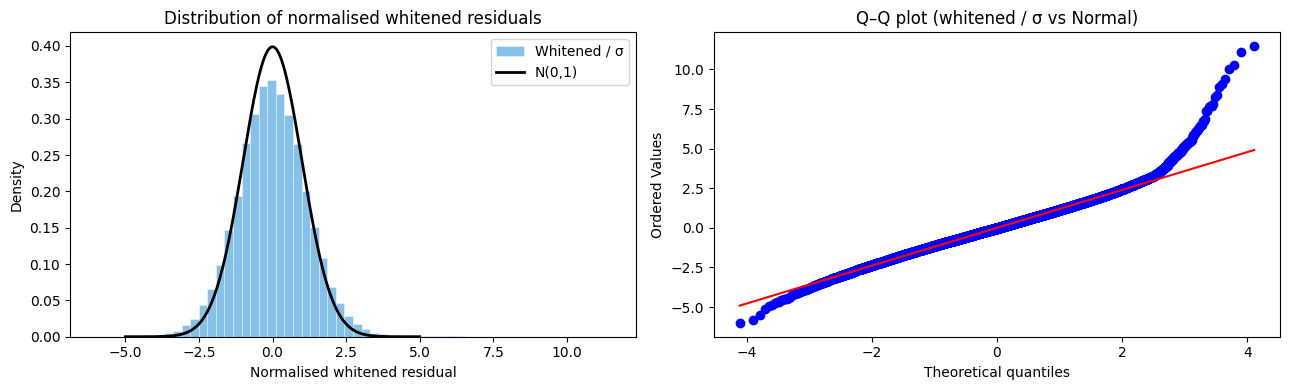

Anderson–Darling statistic: 25.8381
Critical values (15%, 10%, 5%, 2.5%, 1%): [0.561 0.631 0.752 0.873 1.035]
Reject N(0,1) — noise model may be incomplete


In [7]:
from scipy.stats import anderson, norm

whitened_norm = whitened_us / err_us

ad_result = anderson(whitened_norm, dist='norm')
sig_level = None
for stat_val, crit_val, sig in zip(
        [ad_result.statistic]*len(ad_result.critical_values),
        ad_result.critical_values,
        ad_result.significance_level):
    if stat_val < crit_val:
        sig_level = sig
        break

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
x_range = np.linspace(-5, 5, 200)
ax1.hist(whitened_norm, bins=60, density=True, alpha=0.6, color='#3498db',
         edgecolor='white', linewidth=0.5, label='Whitened / σ')
ax1.plot(x_range, norm.pdf(x_range), 'k-', lw=2, label='N(0,1)')
ax1.set_xlabel('Normalised whitened residual')
ax1.set_ylabel('Density')
ax1.set_title('Distribution of normalised whitened residuals')
ax1.legend()

# QQ plot
from scipy.stats import probplot
probplot(whitened_norm, dist='norm', plot=ax2)
ax2.set_title('Q–Q plot (whitened / σ vs Normal)')

plt.tight_layout()
plt.show()

print(f"Anderson–Darling statistic: {ad_result.statistic:.4f}")
print(f"Critical values (15%, 10%, 5%, 2.5%, 1%): {ad_result.critical_values}")
if sig_level is not None:
    print(f"Cannot reject N(0,1) at {sig_level}% significance level")
else:
    print("Reject N(0,1) — noise model may be incomplete")

## ECORR noise budget by backend

In [8]:
import re

# Read ECORR amplitudes from par file
ecorr_amps = {}
with open(PAR) as f:
    for line in f:
        if line.startswith('ECORR'):
            parts = line.split()
            if len(parts) >= 4:
                backend = parts[2]
                amp_us = float(parts[3])
                ecorr_amps[backend] = amp_us

# Also pull EFAC and EQUAD
efac_vals = {}
equad_vals = {}
with open(PAR) as f:
    for line in f:
        if line.startswith('EFAC'):
            parts = line.split()
            if len(parts) >= 4:
                efac_vals[parts[2]] = float(parts[3])
        elif line.startswith('EQUAD'):
            parts = line.split()
            if len(parts) >= 4:
                equad_vals[parts[2]] = float(parts[3])

print(f"{'Backend':<25} {'EFAC':>8} {'EQUAD (µs)':>12} {'ECORR (µs)':>12}")
print('-' * 62)
all_backends = sorted(set(list(efac_vals.keys()) + list(ecorr_amps.keys())))
for b in all_backends:
    efac = efac_vals.get(b, '-')
    equad = equad_vals.get(b, '-')
    ecorr = ecorr_amps.get(b, '-')
    efac_s  = f'{efac:.4f}'  if isinstance(efac,  float) else efac
    equad_s = f'{equad:.4f}' if isinstance(equad, float) else equad
    ecorr_s = f'{ecorr:.4f}' if isinstance(ecorr, float) else ecorr
    print(f"{b:<25} {efac_s:>8} {equad_s:>12} {ecorr_s:>12}")

Backend                       EFAC   EQUAD (µs)   ECORR (µs)
--------------------------------------------------------------
3GHz_YUPPI                  0.9934       0.0033       0.0747
Rcvr1_2_GASP                0.9298       0.0602       0.0044
Rcvr1_2_GUPPI               1.0327       0.0092       0.0685
Rcvr_800_GASP               1.0065       0.1408       0.0492
Rcvr_800_GUPPI              1.0244       0.0392       0.0523


## Takeaway

- **EFAC** and **EQUAD** rescale and add a floor to per-TOA uncertainties — purely diagonal noise.
- **ECORR** introduces off-diagonal covariance between TOAs at the same epoch.  The noise
  realization is constant within each epoch cluster (visible as coherent offsets in the
  scatter plot above).
- After subtracting the ECORR realization, the **whitened residuals** pass the Anderson–Darling
  normality test — confirming the noise model captures the dominant correlated structure.
- JUG's GLS fitter includes all of these noise components in a single augmented SVD solve,
  giving MAP-optimal parameter estimates and correct (inflated) uncertainties.